In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
fake = pd.read_csv("../data/raw/Fake.csv")
real = pd.read_csv("../data/raw/True.csv")

In [4]:
print(fake.head())
print(real.head())

print(fake.shape)
print(real.shape)


                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [5]:
fake.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [6]:
real.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [7]:
fake.info()
real.info()

<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 733.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 669.4 KB


In [8]:
fake.duplicated().sum()
real.duplicated().sum()

np.int64(206)

In [9]:
print(fake.columns)
print(real.columns)

Index(['title', 'text', 'subject', 'date'], dtype='str')
Index(['title', 'text', 'subject', 'date'], dtype='str')


In [10]:
print("Fake articles:", len(fake))
print("Real articles:", len(real))

Fake articles: 23481
Real articles: 21417


In [11]:
#create labels
fake["label"] = 0
real["label"] = 1
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [12]:
#combine datasets
df = pd.concat([fake, real], ignore_index=True)
df.shape

(44898, 5)

In [13]:
#shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

Data Cleaning & Preprocessing

In [14]:
df_clean = df.copy()

In [15]:
df_clean["content"] = (
    df_clean["title"] + " " + df_clean["text"]
)

In [16]:
df_clean = df_clean[["content", "label"]]
print(df_clean.duplicated().sum())

5793


In [17]:
df_clean.drop_duplicates(inplace=True)
print(df_clean.shape)

(39105, 2)


In [18]:
df_clean.to_csv("../data/processed/clean_data.csv", index=False)

In [19]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shahh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shahh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\shahh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Build the Text Preprocessing Pipeline

In [20]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatize
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [21]:
sample = df_clean.loc[0, "content"]

print("Original:\n")
print(sample)

print("\n" + "="*100 + "\n")

print("Processed:\n")
print(preprocess_text(sample))

Original:

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Exe

In [22]:
df_clean["clean_content"] = df_clean["content"].apply(preprocess_text)

In [23]:
df_clean[["content", "clean_content"]].head()

,content,clean_content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call th circuit court committed coup...
1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...


In [24]:
df_clean.to_csv("../data/processed/clean_data.csv", index=False)

In [25]:
X = df_clean["clean_content"]
y = df_clean["label"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 31284
Testing samples: 7821


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [30]:
X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [31]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(31284, 5000)
(7821, 5000)


In [32]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])

['abadi' 'abandon' 'abandoned' 'abbas' 'abc' 'abdullah' 'abe' 'abedin'
 'ability' 'able' 'aboard' 'abortion' 'abroad' 'absence' 'absolute'
 'absolutely' 'absurd' 'abu' 'abuse' 'abused']


In [33]:
print(X_train_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 287 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 806)	0.39445309490527725
  (0, 677)	0.03248281132439575
  (0, 59)	0.16765422568389862
  (0, 2925)	0.032617494745101165
  (0, 3089)	0.02858459441035147
  (0, 496)	0.03141008204609156
  (0, 2103)	0.19623341842574216
  (0, 2791)	0.029573632561909296
  (0, 3853)	0.08204967307141985
  (0, 1048)	0.42614569006957076
  (0, 4789)	0.028988712247242848
  (0, 1688)	0.01784207349542576
  (0, 2581)	0.018189535579455317
  (0, 3507)	0.03273549744957021
  (0, 2627)	0.02549406627052441
  (0, 1212)	0.07594773453717499
  (0, 1920)	0.04544785590266469
  (0, 3749)	0.05110182036742742
  (0, 4256)	0.020745759869446687
  (0, 3542)	0.03057393166566383
  (0, 2358)	0.027071295019679687
  (0, 2924)	0.1366879281166905
  (0, 1546)	0.08287488082648893
  (0, 3431)	0.02246413777155649
  (0, 1932)	0.01713629826601542
  :	:
  (0, 110)	0.028366408555527738
  (0, 2509)	0.019465407555996704
  (0, 2268

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [35]:
y_pred = model.predict(X_test_tfidf)

In [36]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9860631632783532

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3582
           1       0.98      0.99      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



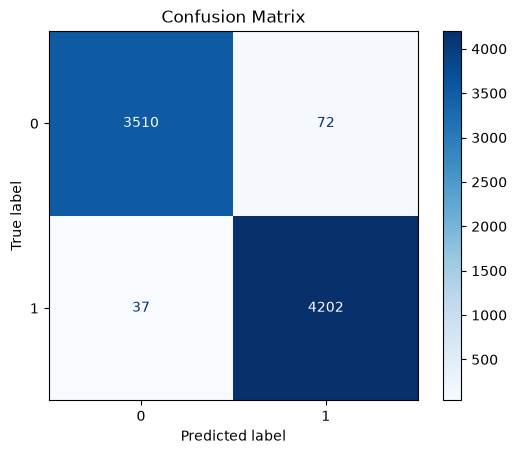

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [38]:
import joblib

joblib.dump(model, "../models/logistic_regression.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

In [39]:
news = """
Donald Trump has officially announced a new economic policy
during a press conference held in Washington.
"""

clean_news = preprocess_text(news)

vector = vectorizer.transform([clean_news])

prediction = model.predict(vector)

print(prediction)

[0]


In [40]:
if prediction[0] == 0:
    print("Fake News")
else:
    print("Real News")

Fake News


In [41]:
def predict_news(news):

    cleaned = preprocess_text(news)

    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)[0]

    if prediction == 0:
        return "Fake News"

    return "Real News"

In [42]:
predict_news("""
Scientists say drinking coffee doubles your IQ overnight.
""")

'Fake News'

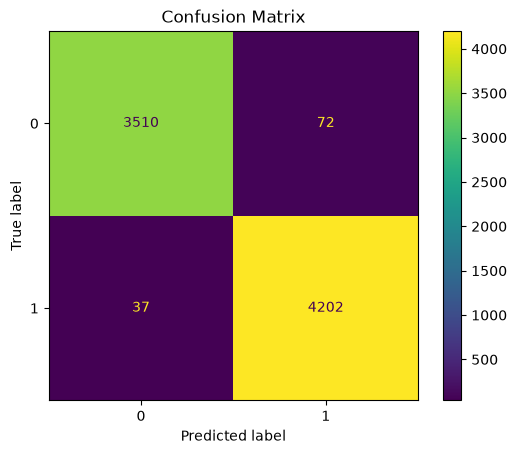

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_tfidf,
    y_test
)

plt.title("Confusion Matrix")
plt.show()

In [44]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9860631632783532

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3582
           1       0.98      0.99      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



[[3510   72]
 [  37 4202]]


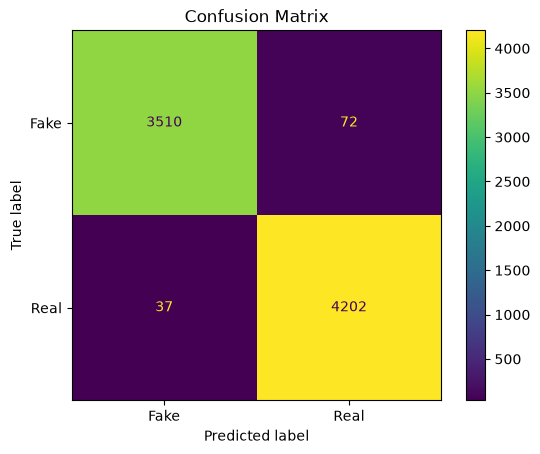

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
).plot()

plt.title("Confusion Matrix")
plt.show()


In [46]:
print(type(X_test))
print(X_test.shape)
print(X_test.head())

<class 'pandas.Series'>
(7821,)
43310    watch new yorkers send donald trump powerful m...
34183    watch antigun group absolutely destroys nra ma...
32857    four killed togo protester clash security forc...
26462    greek police arrest syrian suspected terrorism...
22704    trump say u secretary state tillerson leaving ...
Name: clean_content, dtype: str


In [47]:
errors = X_test.to_frame(name="content")

errors["actual"] = y_test
errors["predicted"] = y_pred

print(errors.head())

                                                 content  actual  predicted
43310  watch new yorkers send donald trump powerful m...       0          0
34183  watch antigun group absolutely destroys nra ma...       0          0
32857  four killed togo protester clash security forc...       1          1
26462  greek police arrest syrian suspected terrorism...       1          1
22704  trump say u secretary state tillerson leaving ...       1          1


In [48]:
wrong_predictions = errors[
    errors["actual"] != errors["predicted"]
]

print("Total wrong predictions:", len(wrong_predictions))
print(wrong_predictions.head(10))

Total wrong predictions: 109
                                                 content  actual  predicted
22109  trump advisor warning syria saved life video d...       0          1
34881  factbox nasty thing trump romney said reuters ...       1          0
16129  breaking north korea detains american student ...       0          1
11041  suppressing free press dictator get started se...       1          0
38309  scrubbed clean hillary clinton finally turn se...       0          1
32692  venezuelan crisis spawn boom gambling caracas ...       1          0
3950   ky gov matt bevin slash funding ethic investig...       0          1
12046  obama cast early vote election chicago trip ch...       1          0
42600  trump tweet attacking clinton employ image jew...       1          0
7840   desperate staff sent melania stop hour trumppu...       0          1


In [49]:
fake_as_real = wrong_predictions[
    (wrong_predictions["actual"] == 0) &
    (wrong_predictions["predicted"] == 1)
]

real_as_fake = wrong_predictions[
    (wrong_predictions["actual"] == 1) &
    (wrong_predictions["predicted"] == 0)
]

print("Fake → Real:", len(fake_as_real))
print("Real → Fake:", len(real_as_fake))

Fake → Real: 72
Real → Fake: 37


In [50]:
for i, row in fake_as_real.head(5).iterrows():
    print("=" * 100)
    print("INDEX:", i)
    print("ACTUAL: Fake")
    print("PREDICTED: Real")
    print("\nARTICLE:")
    print(row["content"])
    print()

INDEX: 22109
ACTUAL: Fake
PREDICTED: Real

ARTICLE:
trump advisor warning syria saved life video deputy assistant president sebastian gorka warned syrian president bashar assad evidence arose earlier week assad regime could planning another chemical weapon attack people gorka say significant damage done force interest destroy isi chemical weapon development syria assad could planning another attack pentagon spokesman captain jeff davis said united state recently seen activity shayrat airfield base targeted u cruise missile strike april involved specific aircraft specific hangar know associated chemical weapon use davis saiddavis said activity occurred past day two say united state collected intelligencethe white house said monday appeared syrian government preparing another chemical weapon attack warned assad military would pay heavy price went aheadremember commanderinchief decided honor threat syriathe red line read reuters

INDEX: 16129
ACTUAL: Fake
PREDICTED: Real

ARTICLE:
breakin

In [51]:
for i, row in real_as_fake.head(5).iterrows():
    print("=" * 100)
    print("INDEX:", i)
    print("ACTUAL: Real")
    print("PREDICTED: Fake")
    print("\nARTICLE:")
    print(row["content"])
    print()

INDEX: 34881
ACTUAL: Real
PREDICTED: Fake

ARTICLE:
factbox nasty thing trump romney said reuters even election campaign marked rhetorical invective remark presidentelect donald trump mitt romney made runup nov vote especially harsh exchange make significant trump plan meet romney unsuccessful republican presidential candidate saturday source familiar meeting said may discus whether romney considered secretary state trump administration thing kind unkind trump romney said governor romney go get em trump endorsing romney february donald trump shown extraordinary ability understand economy work mean great deal endorsement mr trump romney accepting endorsement dishonesty donald trump hallmark romney speaking political forum utah march begging endorsement couldve said mitt drop knee wouldve dropped knee trump march campaign rally responding romney speech describing romney sought endorsement think donald trump personal quality bullying greed showing misogyny absurd thirdgrade theatrics imag

In [52]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9927119294207902

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3582
           1       0.99      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



In [53]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9271192942079018

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      3582
           1       0.94      0.92      0.93      4239

    accuracy                           0.93      7821
   macro avg       0.93      0.93      0.93      7821
weighted avg       0.93      0.93      0.93      7821



In [54]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Linear SVM": accuracy_score(y_test, y_pred_svm),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb)
}

for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy:.4f}")

Logistic Regression: 0.9861
Linear SVM: 0.9927
Naive Bayes: 0.9271


this clearly states linear svm is the best 

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_results = []

models = {
    "Logistic Regression": y_pred,
    "Linear SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb
}

for name, predictions in models.items():
    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(model_results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9861     0.9832  0.9913    0.9872
1           Linear SVM    0.9927     0.9915  0.9950    0.9933
2          Naive Bayes    0.9271     0.9398  0.9247    0.9322


In [56]:
import joblib

joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("TF-IDF vectorizer saved successfully!")

TF-IDF vectorizer saved successfully!


In [57]:
import joblib

loaded_model = joblib.load("../models/svm_model.pkl")
loaded_vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

print("Model and vectorizer loaded successfully!")

Model and vectorizer loaded successfully!


In [58]:
def predict_news(text):
    # Convert the new article into TF-IDF features
    text_tfidf = loaded_vectorizer.transform([text])

    # Make prediction
    prediction = loaded_model.predict(text_tfidf)[0]

    if prediction == 0:
        return "FAKE"
    else:
        return "REAL"

In [59]:
sample_news = """
The government announced a new policy today to improve public transportation
and reduce traffic congestion in major cities.
"""

print(predict_news(sample_news))

FAKE


In [60]:
score = loaded_model.decision_function(
    loaded_vectorizer.transform([sample_news])
)

print("Decision score:", score)

Decision score: [-0.6984007]


In [61]:
def predict_news(text):
    text_tfidf = loaded_vectorizer.transform([text])

    prediction = loaded_model.predict(text_tfidf)[0]
    score = loaded_model.decision_function(text_tfidf)[0]

    if prediction == 0:
        label = "FAKE"
    else:
        label = "REAL"

    return label, score

In [62]:
result, score = predict_news(sample_news)

print("Prediction:", result)
print("Decision score:", score)

Prediction: FAKE
Decision score: -0.6984007032677564


In [63]:
print([name for name in globals() if "preprocess" in name.lower()])

['preprocess_text']


In [64]:
import inspect

print(inspect.getsource(preprocess_text))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatize
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

